<a href="https://colab.research.google.com/github/shiiid/PremierLeague2024-2025/blob/main/Visualisasi_data_Shidqi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

In [6]:
from google.colab import files
uploaded = files.upload()

Saving Squad_PlayerStats__stats_standard.csv to Squad_PlayerStats__stats_standard (1).csv


In [9]:
df = pd.read_csv('Squad_PlayerStats__stats_standard.csv')

df.head()

,Rk,Player,Nation,Pos,Squad,Age,Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,...,Performance_PK,Performance_PKatt,Performance_CrdY,Performance_CrdR,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_G-PK,Per 90 Minutes_G+A-PK,Matches
0,1,Max Aarons,eng ENG,DF,Bournemouth,24.0,2000.0,3,1,86,...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,Matches
1,2,Joshua Acheampong,eng ENG,DF,Chelsea,18.0,2006.0,4,2,170,...,0,0,1,0,0.00,0.00,0.00,0.00,0.00,Matches
2,3,Tyler Adams,us USA,MF,Bournemouth,25.0,1999.0,28,21,1965,...,0,0,7,0,0.00,0.14,0.14,0.00,0.14,Matches
3,4,Tosin Adarabioyo,eng ENG,DF,Chelsea,26.0,1997.0,22,15,1409,...,0,0,4,0,0.06,0.06,0.13,0.06,0.13,Matches
4,5,Simon Adingra,ci CIV,MF,Brighton,22.0,2002.0,29,12,1097,...,0,0,0,0,0.16,0.16,0.33,0.16,0.33,Matches


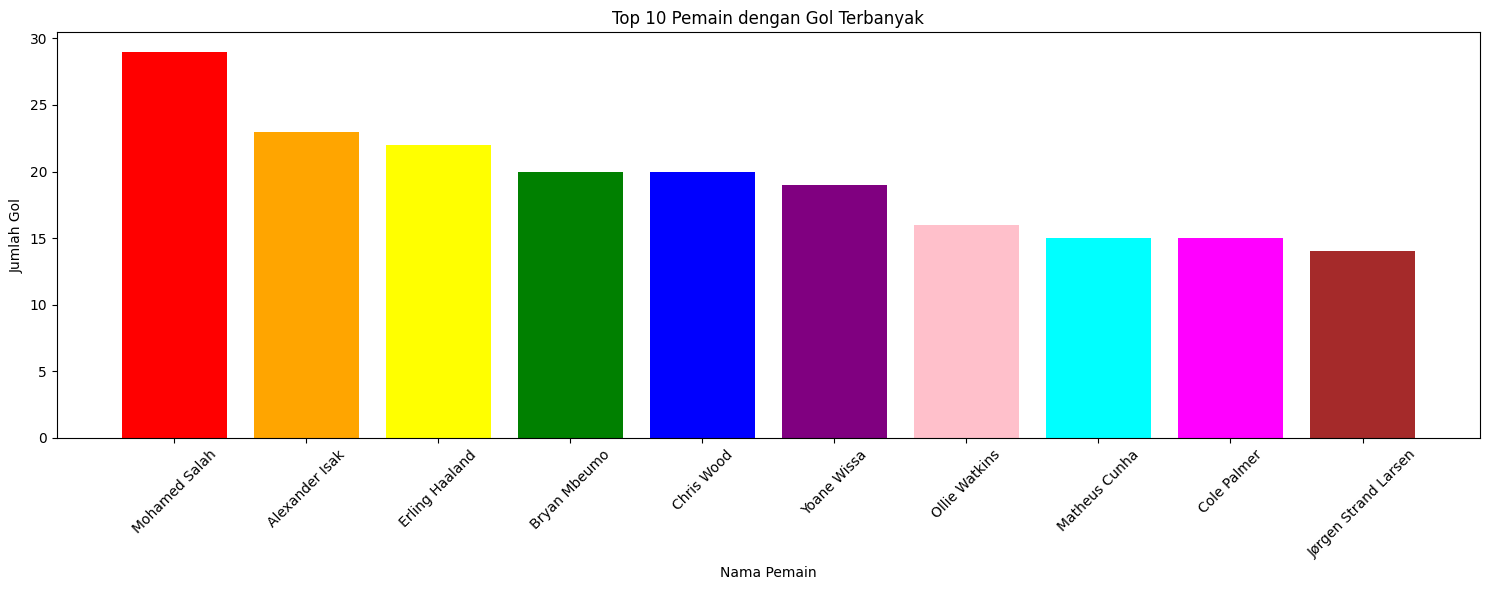

In [10]:
#BAR CHART TOP SCORER

plt.figure(figsize=(15,6))

# Mengambil 10 pemain dengan gol terbanyak
top_scorers = df.sort_values(by='Performance_Gls', ascending=False).head(10)

pemain = top_scorers['Player']
gol = top_scorers['Performance_Gls']

warna = ['red','orange','yellow','green','blue','purple','pink','cyan','magenta','brown']

plt.bar(pemain, gol, color=warna)

plt.xlabel('Nama Pemain')
plt.ylabel('Jumlah Gol')
plt.title('Top 10 Pemain dengan Gol Terbanyak')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

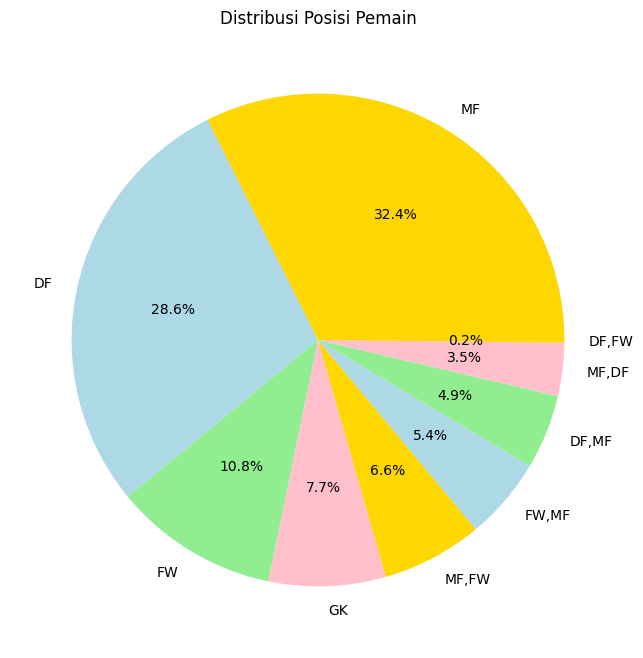

In [11]:
#PIE CHART DISTRIBUSI POSISI PEMAIN

plt.figure(figsize=(8,8))

posisi = df['Pos'].value_counts()

label = posisi.index
nilai = posisi.values

warna = ['gold','lightblue','lightgreen','pink']

plt.pie(nilai, labels=label, autopct='%1.1f%%', colors=warna)

plt.title('Distribusi Posisi Pemain')

plt.show()

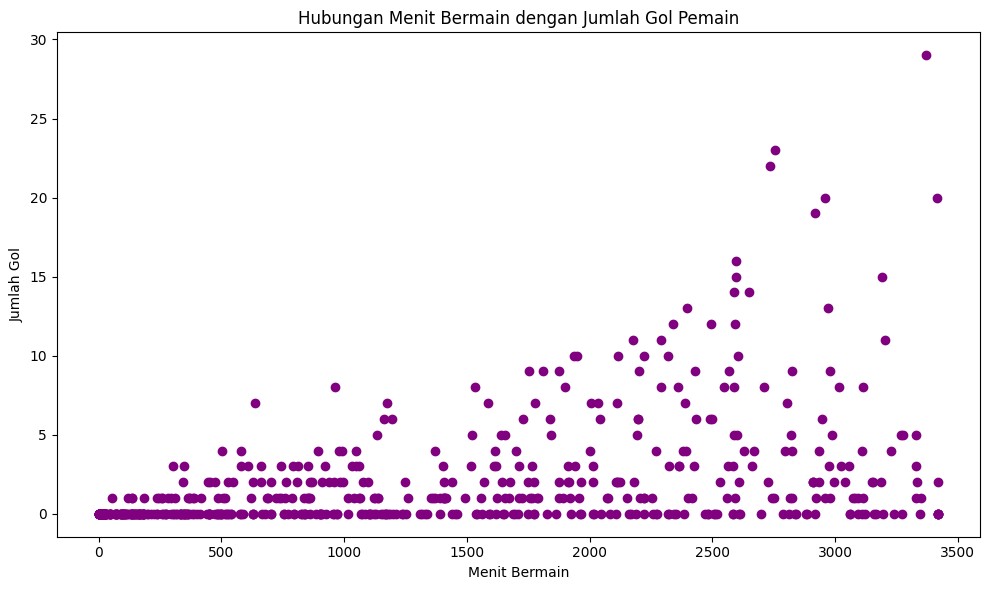

In [12]:
#SCATTER PLOT MENIT BERMAIN VS GOL

plt.figure(figsize=(10,6))

plt.scatter(df['Playing Time_Min'], df['Performance_Gls'], color='purple')

plt.xlabel('Menit Bermain')
plt.ylabel('Jumlah Gol')
plt.title('Hubungan Menit Bermain dengan Jumlah Gol Pemain')

plt.tight_layout()
plt.show()

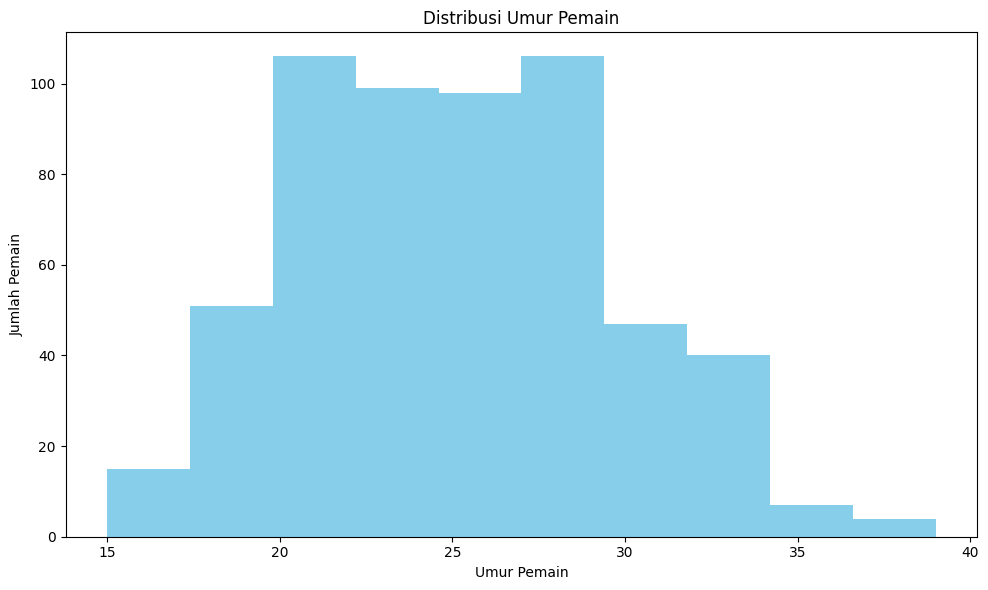

In [13]:
#HISTOGRAM DISTRIBUSI UMUR PEMAIN

plt.figure(figsize=(10,6))

plt.hist(df['Age'], bins=10, color='skyblue')

plt.xlabel('Umur Pemain')
plt.ylabel('Jumlah Pemain')
plt.title('Distribusi Umur Pemain')

plt.tight_layout()
plt.show()

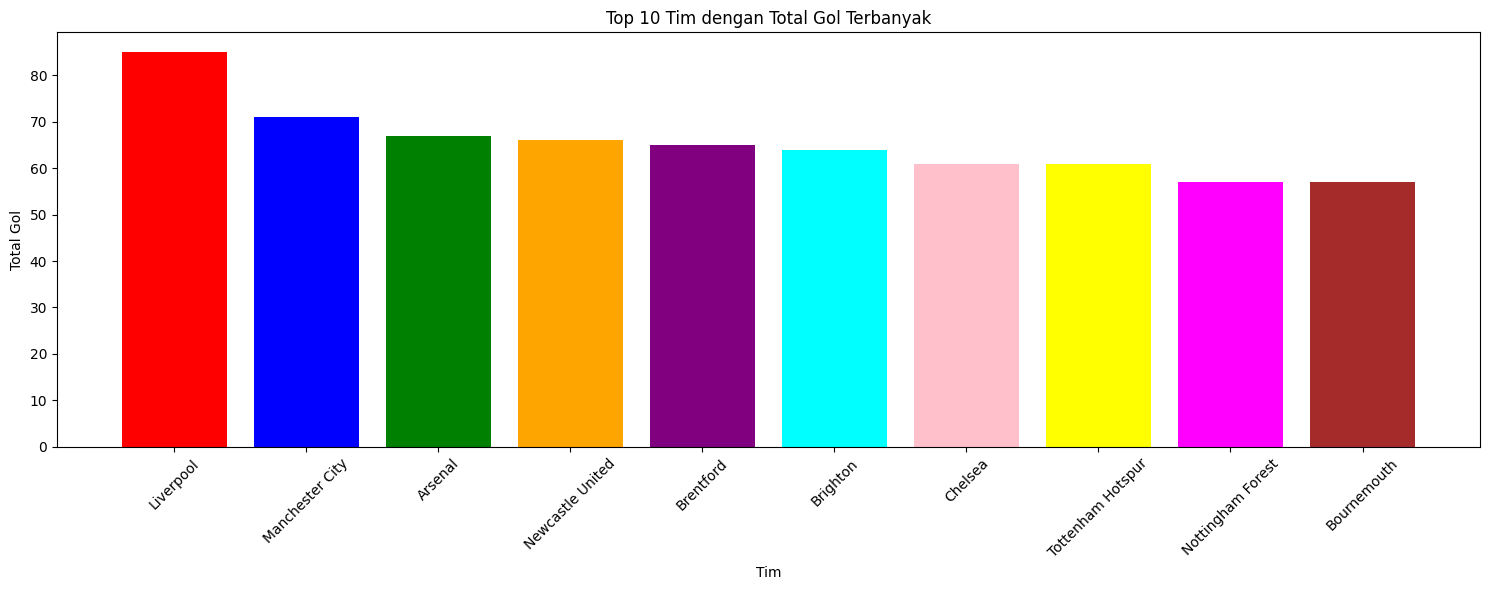

In [15]:
#BAR CHART TOTAL GOL PER TIM

plt.figure(figsize=(15,6))

team_goals = df.groupby('Squad')['Performance_Gls'].sum().sort_values(ascending=False).head(10)

kategori = team_goals.index
nilai = team_goals.values

warna = ['red','blue','green','orange','purple','cyan','pink','yellow','magenta','brown']

plt.bar(kategori, nilai, color=warna)

plt.xlabel('Tim')
plt.ylabel('Total Gol')
plt.title('Top 10 Tim dengan Total Gol Terbanyak')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

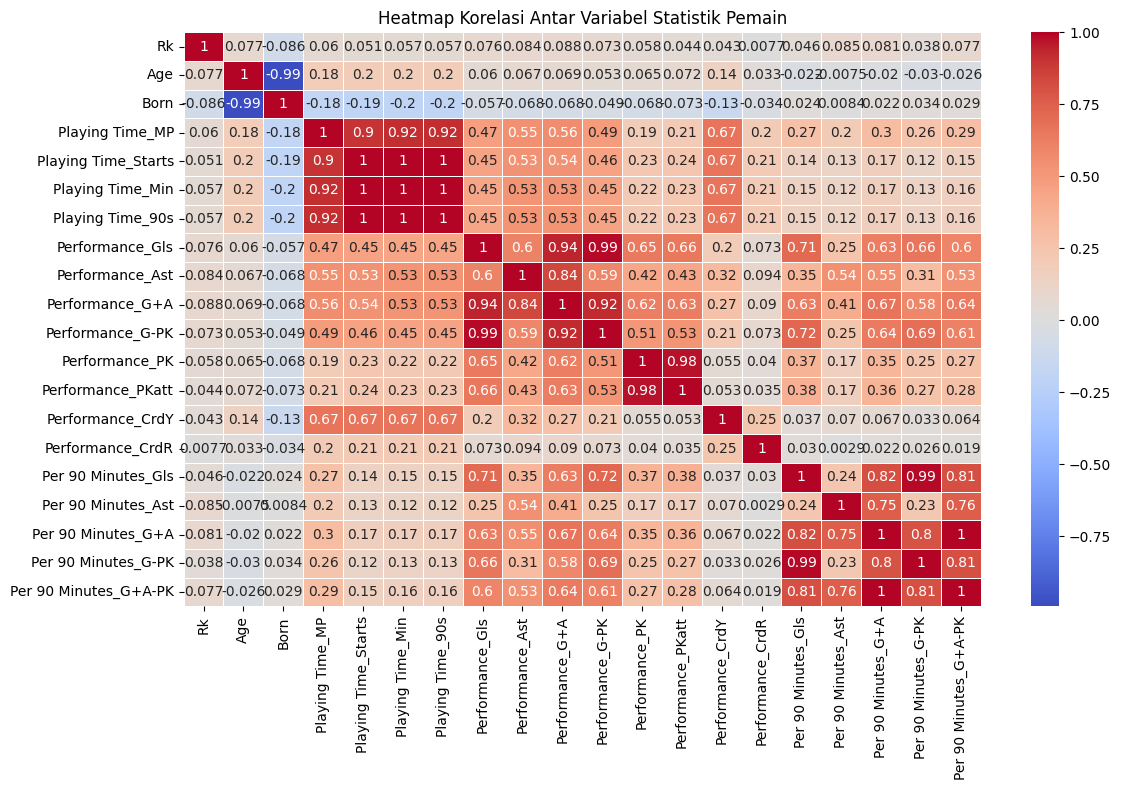

In [16]:
#HEATMAP KORELASI

plt.figure(figsize=(12,8))

numeric_data = df.select_dtypes(include=['float64','int64'])

corr_matrix = numeric_data.corr()

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title('Heatmap Korelasi Antar Variabel Statistik Pemain')

plt.tight_layout()
plt.show()

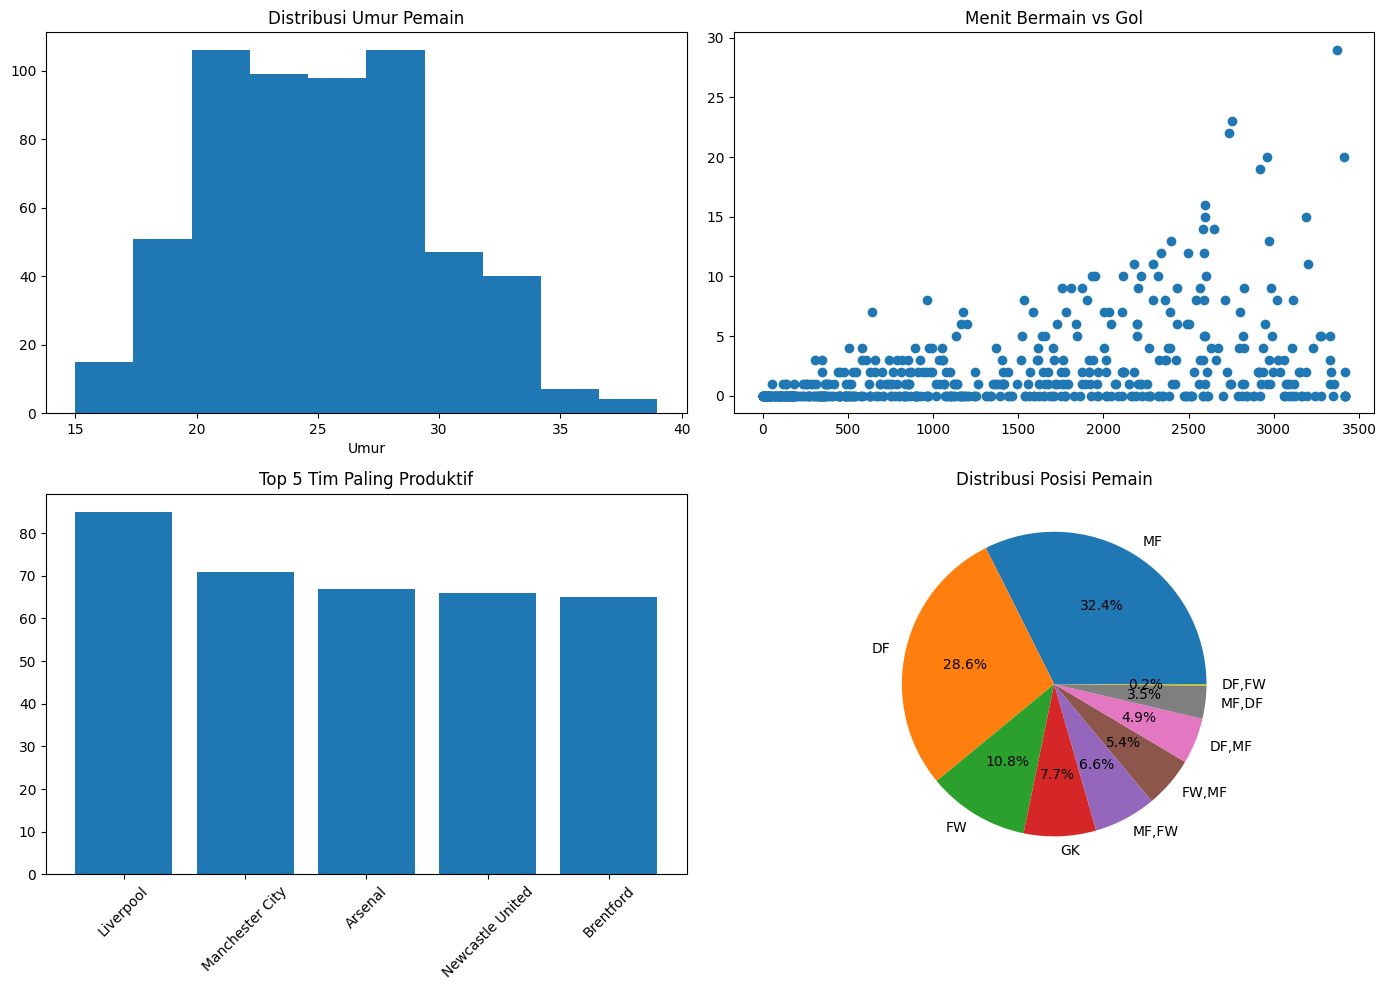

In [21]:
#DASHBOARD ANALISIS SEPAK BOLA

fig, axes = plt.subplots(2,2, figsize=(14,10))

# 1. Distribusi umur
axes[0,0].hist(df['Age'], bins=10)
axes[0,0].set_title('Distribusi Umur Pemain')
axes[0,0].set_xlabel('Umur')

# 2. Gol vs menit bermain
axes[0,1].scatter(df['Playing Time_Min'], df['Performance_Gls'])
axes[0,1].set_title('Menit Bermain vs Gol')

# 3. Top tim dengan gol terbanyak
team_goals = df.groupby('Squad')['Performance_Gls'].sum().sort_values(ascending=False).head(5)
axes[1,0].bar(team_goals.index, team_goals.values)
axes[1,0].set_title('Top 5 Tim Paling Produktif')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Distribusi posisi
posisi = df['Pos'].value_counts()
axes[1,1].pie(posisi.values, labels=posisi.index, autopct='%1.1f%%')
axes[1,1].set_title('Distribusi Posisi Pemain')

plt.tight_layout()
plt.show()